In [67]:
from typing import TypedDict, List, Optional
from langgraph.graph import StateGraph

In [68]:
class AgentState(TypedDict):
    required_number: Optional[int]
    guess: Optional[int]
    guesses: List[int]
    lower_bound: int
    upper_bound: int
    max_guesses: int

In [73]:
from typing import Literal
import random

def select_number(state: AgentState) -> dict:
    return {
    'required_number': random.randint(state['lower_bound'], state['upper_bound'])
    }

def make_guess(state: AgentState) -> AgentState:
    guess = (state["lower_bound"] + state["upper_bound"]) // 2
    
    required_number = state['required_number']
    
    assert required_number is not None
    
    if guess > required_number:
        state['upper_bound'] = guess
    elif guess < required_number:
        state['lower_bound'] = guess
    state['guesses'].append(guess)
    state['guess'] = guess
    
    return state


def should_continue(state: AgentState) -> Literal['stop', 'retry']:
    required_number = state['required_number']
    guessed_number = state.get('guess', 0)
    
    if(guessed_number == required_number):
        print(f'Number {required_number} figured out in {len(state["guesses"] )} guesses')
        return 'stop'
    if len(state["guesses"]) == state['max_guesses']:
        print("max_guesses reached and not found")
        return 'stop'
    else:
        return 'retry'

In [74]:
from langgraph.graph import END, START


graph = StateGraph(AgentState)

graph.add_node("initial", select_number)
graph.add_node('guess', make_guess)

graph.add_edge(START, "initial")
graph.add_edge("initial", "guess")

graph.add_conditional_edges('guess', should_continue, {
    'stop': END,
    'retry': 'guess'
})

app = graph.compile()

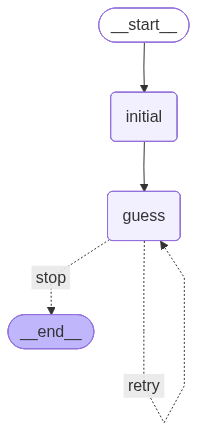

In [75]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [80]:
result = app.invoke({
    'lower_bound': 1,
    'upper_bound': 200,
    'guesses': list(),
    'max_guesses': 10,
    'required_number': None,
    'guess': None
})

result

Number 2 figured out in 7 guesses


{'required_number': 2,
 'guess': 2,
 'guesses': [100, 50, 25, 13, 7, 4, 2],
 'lower_bound': 1,
 'upper_bound': 4,
 'max_guesses': 10}